# 1. Entendimiento del problema
El gobierno Australiano quiere conocer cuanto puede ser el costo de el uso de corticoides y esteroides en el sistema de salud actual para preparar sus finanzas a futuro.

# 2. Enfoque analitico:
Vamos a construir un modelo de regresion basado en series de tiempo que permita estimar el costo de corticoides y esteroides con el menor MAE posible.  

# 3. Requerimiento de datos:
Se requiere los datos pasados del costo de los medicamentos.

# 4. Recolección de datos:

In [2]:
import matplotlib.pyplot as plt
from skforecast.datasets import fetch_dataset

In [ ]:
data = fetch_dataset(name='h2o_exog')
data.index.name = 'datetime'

╭─────────────────────────────────── h2o_exog ────────────────────────────────────╮
│ Description:                                                                    │
│ Monthly expenditure ($AUD) on corticosteroid drugs that the Australian health   │
│ system had between 1991 and 2008. Two additional variables (exog_1, exog_2) are │
│ simulated.                                                                      │
│                                                                                 │
│ Source:                                                                         │
│ Hyndman R (2023). fpp3: Data for Forecasting: Principles and Practice (3rd      │
│ Edition). http://pkg.robjhyndman.com/fpp3package/,                              │
│ https://github.com/robjhyndman/fpp3package, http://OTexts.com/fpp3.             │
│                                                                                 │
│ URL:                                                                            │
│ https://raw.githubusercontent.com/skforecast/skforecast-                        │
│ datasets/main/data/h2o_exog.csv                                                 │
│                                                                                 │
│ Shape: 195 rows x 3 columns                                                     │
╰─────────────────────────────────────────────────────────────────────────────────╯

In [4]:
data

,y,exog_1,exog_2
datetime,,,
1992-04-01,0.379808,0.958792,1.166029
1992-05-01,0.361801,0.951993,1.117859
1992-06-01,0.410534,0.952955,1.067942
1992-07-01,0.483389,0.958078,1.097376
1992-08-01,0.475463,0.956370,1.122199
...,...,...,...
2008-02-01,0.761822,1.515840,1.786373
2008-03-01,0.649435,1.506258,1.694264
2008-04-01,0.827887,1.505253,1.627135


# 5. Exploracion de datos
- Determinar la estacionaridad de la serie

In [5]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from skforecast.plot import set_dark_theme

set_dark_theme()

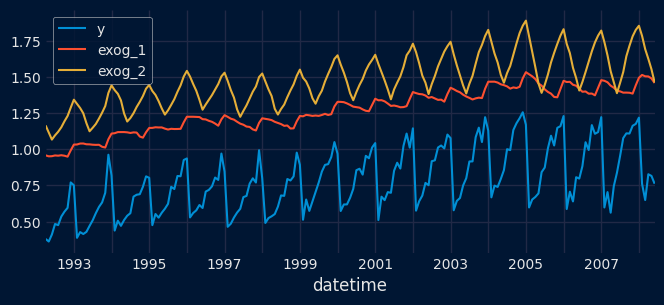

In [6]:
fig, ax = plt.subplots(figsize=(7, 3))
data.plot(ax=ax)
ax.legend()
plt.show()

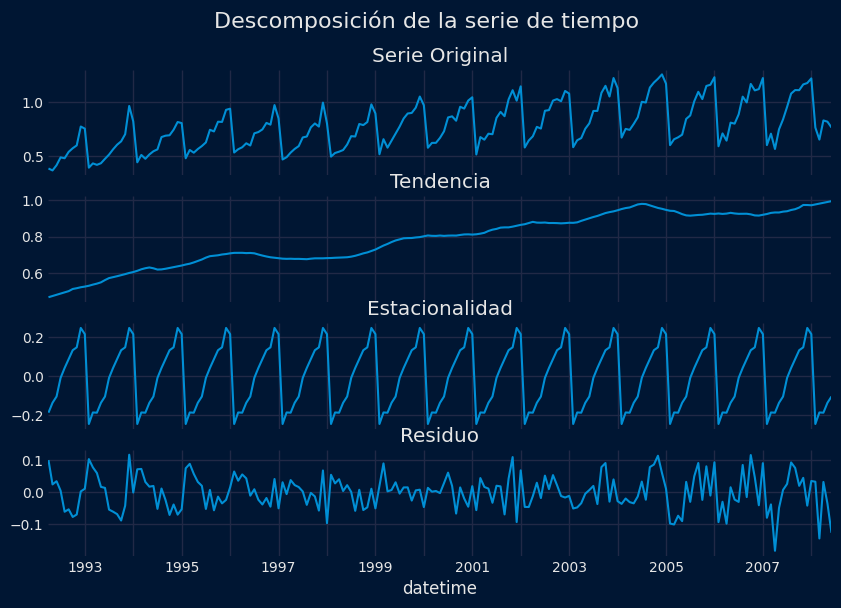

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

res_decompose = seasonal_decompose(data['y'], model='additive', extrapolate_trend='freq')
fig, ax = plt.subplots(4, 1, figsize=(9, 6), sharex=True)

res_decompose.observed.plot(ax=ax[0])
ax[0].set_title('Serie Original')

res_decompose.trend.plot(ax=ax[1])
ax[1].set_title('Tendencia')

res_decompose.seasonal.plot(ax=ax[2])
ax[2].set_title('Estacionalidad')

res_decompose.resid.plot(ax=ax[3])
ax[3].set_title('Residuo')

fig.suptitle('Descomposición de la serie de tiempo', fontsize=16)
plt.show()

In [8]:
def test_estacionaridad(series):
    adfuller_result = adfuller(series)
    print(f'ADF Estadistico: {adfuller_result[0]}')
    print(f'Valor p: {adfuller_result[1]}')

In [9]:
test_estacionaridad(data['y'])

ADF Estadistico: -1.5180458060933468
Valor p: 0.5245662008648657


# 6. Preparacion de datos

- Diferenciar la serie
- Identificar su comportamiento estacional

ADF Estadistico: -3.272501193023123
Valor p: 0.016153320135666022


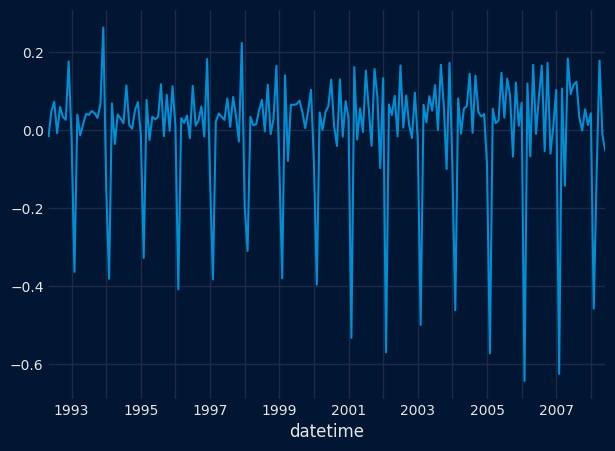

In [10]:
data_diff = data['y'].diff().dropna()
test_estacionaridad(data_diff)
data_diff.plot()
plt.show()

## Obtener valor q

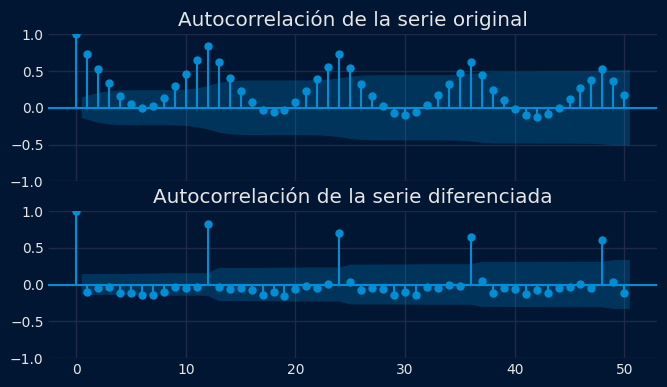

In [11]:
from statsmodels.graphics.tsaplots import plot_acf

# Grafico de autocorrelacion
fig, ax = plt.subplots(2, 1, figsize=(7, 4), sharex=True)

plot_acf(data['y'], ax=ax[0], lags=50, alpha=0.05)
ax[0].set_title('Autocorrelación de la serie original')

plot_acf(data_diff, ax=ax[1], lags=50, alpha=0.05)
ax[1].set_title('Autocorrelación de la serie diferenciada')

plt.show()

## Obtener valor p

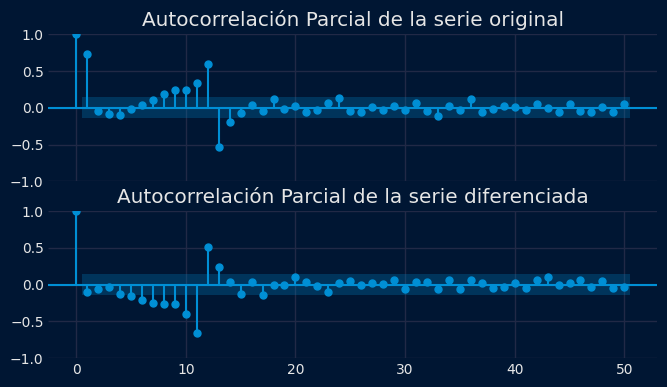

In [12]:
from statsmodels.graphics.tsaplots import plot_pacf

# Grafico de autocorrelacion
fig, ax = plt.subplots(2, 1, figsize=(7, 4), sharex=True)

plot_pacf(data['y'], ax=ax[0], lags=50, alpha=0.05)
ax[0].set_title('Autocorrelación Parcial de la serie original')

plot_pacf(data_diff, ax=ax[1], lags=50, alpha=0.05)
ax[1].set_title('Autocorrelación Parcial de la serie diferenciada')

plt.show()

## Diferenciacion de la serie estacionaria

In [17]:
data_diff_12 = data_diff.diff(12).dropna()
test_estacionaridad(data_diff_12)

ADF Estadistico: -5.177607779376001
Valor p: 9.766313840442693e-06


<Figure size 700x300 with 0 Axes>

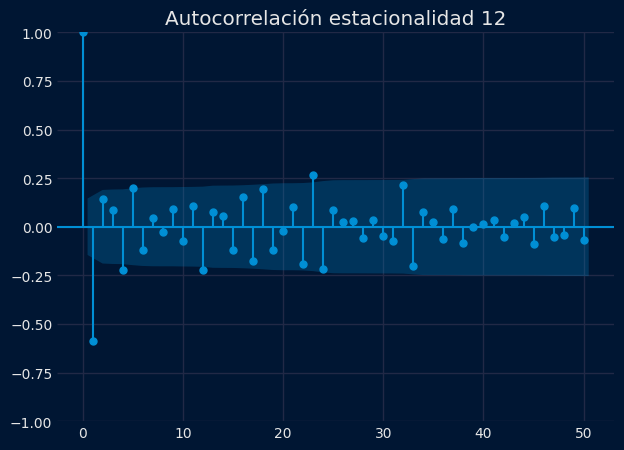

In [23]:
plt.figure(figsize=(7, 3))
plot_acf(data_diff_12, lags=50, alpha=0.05)
plt.title('Autocorrelación estacionalidad 12')
plt.show()

<Figure size 700x300 with 0 Axes>

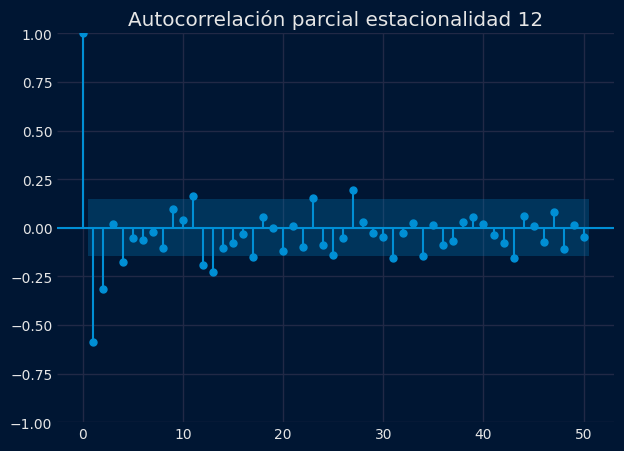

In [24]:
plt.figure(figsize=(7, 3))
plot_pacf(data_diff_12, lags=50, alpha=0.05)
plt.title('Autocorrelación parcial estacionalidad 12')
plt.show()

## Datos extraidos
![WhatsApp Image 2025-10-15 at 08.41.42_1276a518.jpg](<attachment:WhatsApp Image 2025-10-15 at 08.41.42_1276a518.jpg>)
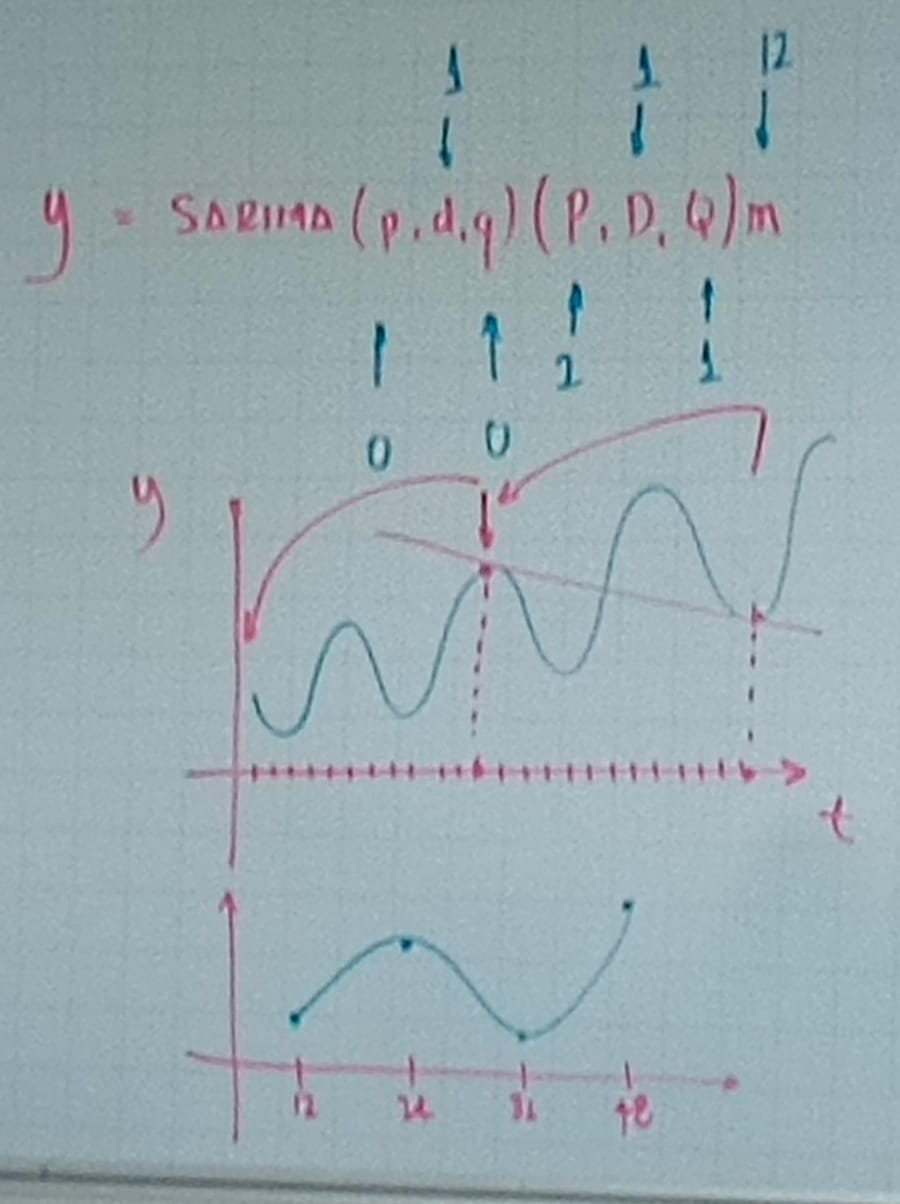

## Separacion datos entrenamiento y prueba

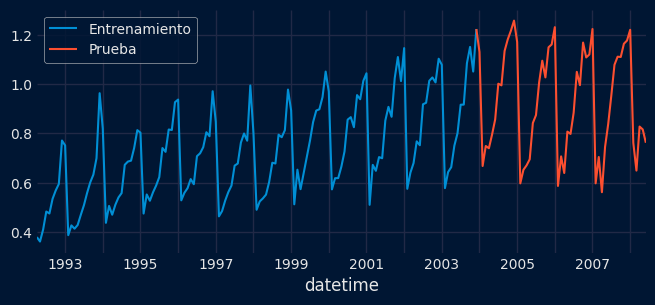

In [26]:
end_train = '2003-12-01'
data_train = data['y'].loc[:end_train]
data_test = data['y'].loc[end_train:]

plt.figure(figsize=(7, 3))
data_train.plot(label='Entrenamiento')
data_test.plot(label='Prueba')
plt.legend()
plt.show()

# 7. Modelado
- SARIMAX
- Forecaster
- RNA Secuencial

## SARIMAX

In [27]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

modelo_sarimax = SARIMAX(data_train, order=(0, 1, 0), seasonal_order=(2, 1, 1, 12))
modelo_sarimax_fit = modelo_sarimax.fit(disp = 0)
modelo_sarimax_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  141
Model:             SARIMAX(0, 1, 0)x(2, 1, [1], 12)   Log Likelihood                 178.682
Date:                              Wed, 15 Oct 2025   AIC                           -349.365
Time:                                      09:28:21   BIC                           -337.957
Sample:                                  04-01-1992   HQIC                          -344.729
                                       - 12-01-2003                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12       0.4001      0.203      1.971      0.049       0.002       0.798
ar.S.L24      -0.2297      0.132     -1.739      0.082      -0.488       0.029
ma.S.L12      -0.8181      0.260     -3.148      0.002      -1.327      -0.309
sigma2         0.0033      0.000      7.708      0.000       0.002       0.004
===================================================================================
Ljung-Box (L1) (Q):                  35.77   Jarque-Bera (JB):                13.19
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               2.59   Skew:                            -0.46
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.27
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [28]:
pred_sarimax = modelo_sarimax_fit.get_forecast(steps=len(data_test)).predicted_mean
pred_sarimax.name = 'predicciones_sarimax'
display(pred_sarimax.head(4))

2004-01-01    1.153860
2004-02-01    0.719788
2004-03-01    0.792595
2004-04-01    0.791223
Freq: MS, Name: predicciones_sarimax, dtype: float64

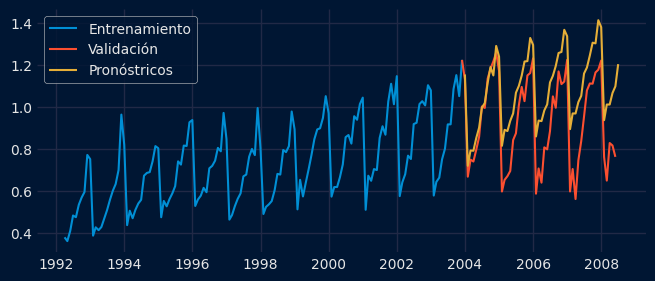

In [29]:
plt.figure(figsize=(7, 3))
plt.plot(data_train, label='Entrenamiento')
plt.plot(data_test, label='Validación')
plt.plot(pred_sarimax, label='Pronóstricos')
plt.legend()
plt.show()

In [31]:
from sklearn.metrics import mean_absolute_percentage_error

mape_sarimax = mean_absolute_percentage_error(data_test, pred_sarimax)
print(f'MAPE: {mape_sarimax}')

MAPE: 0.2636046451459845
